===== FIRST 5 ROWS =====
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horse

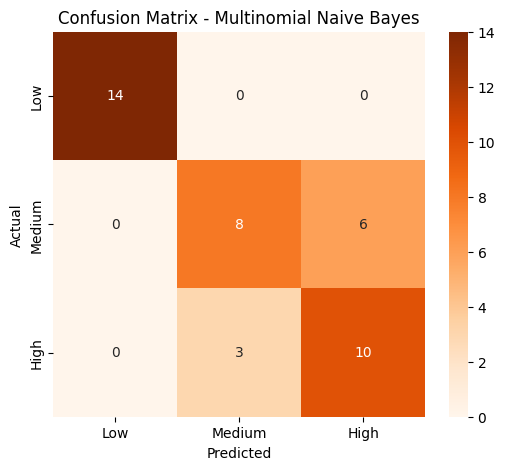


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        14
      Medium       0.73      0.57      0.64        14
        High       0.62      0.77      0.69        13

    accuracy                           0.78        41
   macro avg       0.78      0.78      0.78        41
weighted avg       0.79      0.78      0.78        41


===== ACTUAL VS PREDICTED =====
  Actual  Predicted
0      0          0
1      2          1
2      1          1
3      2          2
4      0          0
5      2          2
6      0          0
7      2          2
8      1          2
9      2          2


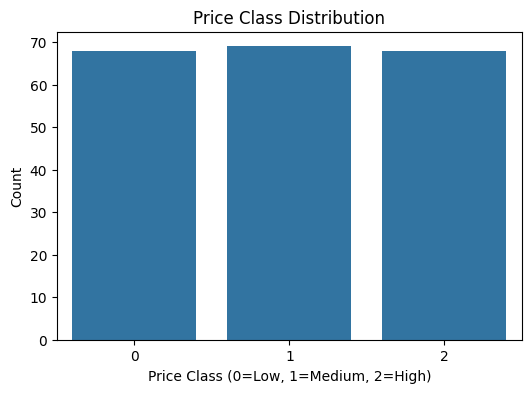


===== NEW CAR PREDICTION =====
Predicted Category: MEDIUM PRICE


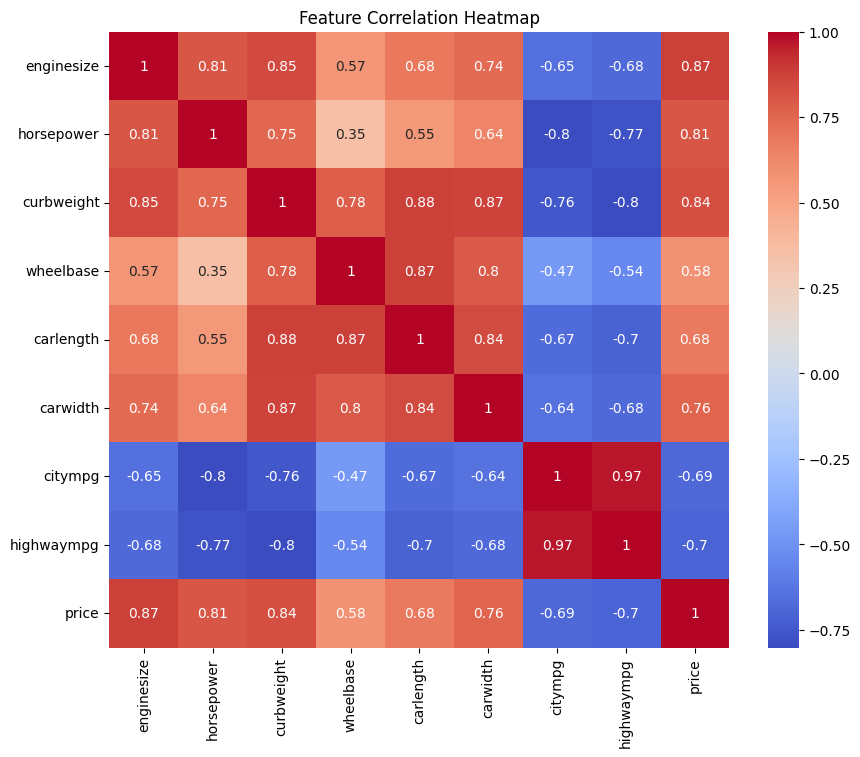

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv('/content/CarPrice_Assignment.csv')

print("===== FIRST 5 ROWS =====")
print(df.head())


df['price_class'] = pd.qcut(df['price'],
                            q=3,
                            labels=[0, 1, 2])

print("\n===== PRICE CLASS DISTRIBUTION =====")
print(df['price_class'].value_counts())

features = [
    'enginesize',
    'horsepower',
    'curbweight',
    'wheelbase',
    'carlength',
    'carwidth',
    'citympg',
    'highwaympg'
]

X = df[features]
y = df['price_class']

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


X_scaled = (X_scaled * 100).astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== TRAIN TEST SHAPES =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


model = MultinomialNB()


model.fit(X_train, y_train)

print("\n===== MODEL TRAINED SUCCESSFULLY =====")

y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\n===== MODEL EVALUATION =====")
print(f"Accuracy Score : {accuracy:.4f}")


cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.show()


print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred,
                            target_names=['Low', 'Medium', 'High']))


results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\n===== ACTUAL VS PREDICTED =====")
print(results.head(10))


plt.figure(figsize=(6,4))
sns.countplot(x=df['price_class'])
plt.title('Price Class Distribution')
plt.xlabel('Price Class (0=Low, 1=Medium, 2=High)')
plt.ylabel('Count')
plt.show()


new_car = pd.DataFrame({
    'enginesize': [130],
    'horsepower': [111],
    'curbweight': [2500],
    'wheelbase': [95],
    'carlength': [170],
    'carwidth': [65],
    'citympg': [25],
    'highwaympg': [32]
})


new_car_scaled = scaler.transform(new_car)
new_car_scaled = (new_car_scaled * 100).astype(int)


prediction = model.predict(new_car_scaled)[0]

class_names = {0: 'LOW PRICE',
               1: 'MEDIUM PRICE',
               2: 'HIGH PRICE'}

print("\n===== NEW CAR PREDICTION =====")
print("Predicted Category:", class_names[prediction])

plt.figure(figsize=(10,8))
sns.heatmap(df[features + ['price']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()